In [2]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_ROOT = Path("vanguard/notebooks").resolve()
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.append(str(NOTEBOOK_ROOT))

import numpy as np
from skeleton3d_utils.skeleton3d import skeletonize3d
from skeleton3d_utils.skeleton3d_visuals import (
    edges_to_segments,
    plot_skeleton3d,
    plot_skeleton_projections,
)
from skeleton3d_utils.skeleton_to_graph import (
    assign_component_labels,
    build_vessel_json,
    detect_bifurcations,
    extract_segments,
    obtain_radius_map,
    segments_to_graph,
)

### Step 1. Import image. 
The image we will be using as input comes from Step 3 of the Prediction Workflow ipynb. The `final_image` has three channels (first dimension), which are probabilities that a given pixel is fibroglandular tissue, blood vessel, or neither. Each channel is represented as a three-dimensional array with probabilities. 

In [3]:
final_image = np.load("vanguard/notebooks/skeleton3d_usage/sample.npy")
print("Probabilities should be between 0 and 1")
print(np.min(final_image), np.max(final_image))
print("The sum of the three channels must be close to 1")
print(np.isclose(np.sum(final_image, axis=0), 1, rtol=0.002).all())

Probabilities should be between 0 and 1
0.0 1.0
The sum of the three channels must be close to 1
True


### Step 2. Keep blood vessels
We will only use channel 1 of each image. Channel 1 represents probabilities of each voxel being part of a blood vessel.

In [4]:
vessels = final_image[1]

In [5]:
print("Shape:", vessels.shape)
print("Data type:", vessels.dtype)
print("Min:", np.min(vessels))
print("Max:", np.max(vessels))
print("Unique values (sample):", np.unique(vessels)[:10])

Shape: (448, 448, 160)
Data type: float16
Min: 0.0
Max: 1.0
Unique values (sample): [0.0e+00 6.0e-08 1.2e-07 1.8e-07 2.4e-07 3.0e-07 3.6e-07 4.2e-07 4.8e-07
 5.4e-07]


### Step 3. Skeletonize 3D image
The next step consists on skeletonize a 3D image using skeletonize3d() and a predefined probability threshold.

In [6]:
skeleton = skeletonize3d(vessels, threshold=0.5)

In [7]:
print("Shape:", skeleton.shape)
print("Data type:", skeleton.dtype)
print("Min:", np.min(skeleton))
print("Max:", np.max(skeleton))
print("Unique values (sample):", np.unique(skeleton)[:10])

Shape: (448, 448, 160)
Data type: uint32
Min: 0
Max: 41943040
Unique values (sample): [ 0  1  2  4  5  8 12 16 32 40]


### Step 4. Visualize the output

In [8]:
segments = edges_to_segments(skeleton)
print(f"{len(segments)} line segments extracted")

4475 line segments extracted


In [9]:
fig = plot_skeleton3d(segments)
fig.show()

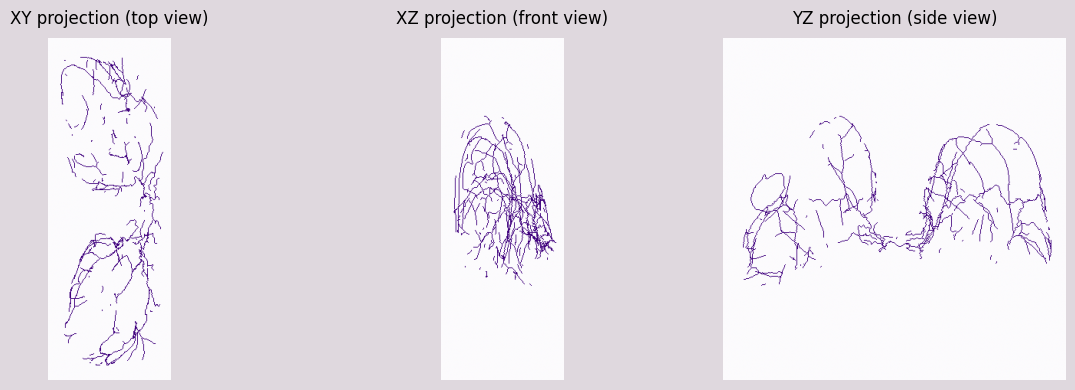

In [10]:
plot_skeleton_projections(skeleton)

### Step 5. Going from Segments to a Graph

Now G is your vessel centerline graph.

In [11]:
G = segments_to_graph(segments)

In [12]:
# Compute local radius map
radius_map = obtain_radius_map(vessels, G)

In [13]:
# Extract anatomycal segments between bifurcations
# Now you have true curved segments, not tiny voxel-to-voxel edges.
segment_paths = extract_segments(G)

In [14]:
bifurcations = detect_bifurcations(G)

In [15]:
vessel_labels = assign_component_labels(G)

In [16]:
build_vessel_json(
    G,
    vessel_labels,
    segment_paths,
    radius_map,
    bifurcations,
    output_path="/home/jmcarias/vanguard/output/skeleton_to_graph_output/vessels_morphometry_try.json",
)

✔ Vessel morphometry JSON saved to: /home/jmcarias/vanguard/output/skeleton_to_graph_output/vessels_morphometry_try.json
